<a href="https://colab.research.google.com/github/MyTeachers123/genai-course/blob/main/week1/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — Comparing GenAI Model Families
**COM SCI-X 455 · Week 1 · Megan Armani, PhD**

> Push your completed notebook to `genai-course/week1/` on GitHub.

---

## Setup

In [15]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [16]:
import torch, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — switch runtime to T4 GPU")

GPU: CPU only — switch runtime to T4 GPU


## Note on Homework Extension
The **lab** uses MNIST. Your **homework** (Part 1) asks you to apply the same VAE to a *different* dataset — FashionMNIST or similar. The loader below shows how to swap datasets:
```python
# Swap MNIST for FashionMNIST in one line:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# Everything else (model, training loop, FID) stays identical.
```
This is intentional — the skill is transferring the architecture, not copy-pasting it.

## Part 1 — VAE on MNIST
**Goal:** Train a Variational Autoencoder, generate digits, observe the blurriness characteristic of VAEs.

In [17]:
# Data loader
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.62MB/s]


In [26]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: image -> mu, log_var
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)
        # Decoder: z -> image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h    = self.encoder(x)
        mu   = self.fc_mu(h)
        lv   = self.fc_var(h)
        z    = self.reparameterise(mu, lv)
        recon = self.decoder(z)
        return recon, mu, lv

def vae_loss(recon, x, mu, lv):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
    return recon_loss

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(5):
    total_loss = 0

    for x, _ in loader:
        x = x.to(device)

        recon, mu, lv = vae(x)
        loss = vae_loss(recon, x, mu, lv)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/5, Loss: {total_loss / len(train_data):.2f}")

Epoch 1/5, Loss: 169.62
Epoch 2/5, Loss: 109.11
Epoch 3/5, Loss: 94.42
Epoch 4/5, Loss: 87.90
Epoch 5/5, Loss: 83.68


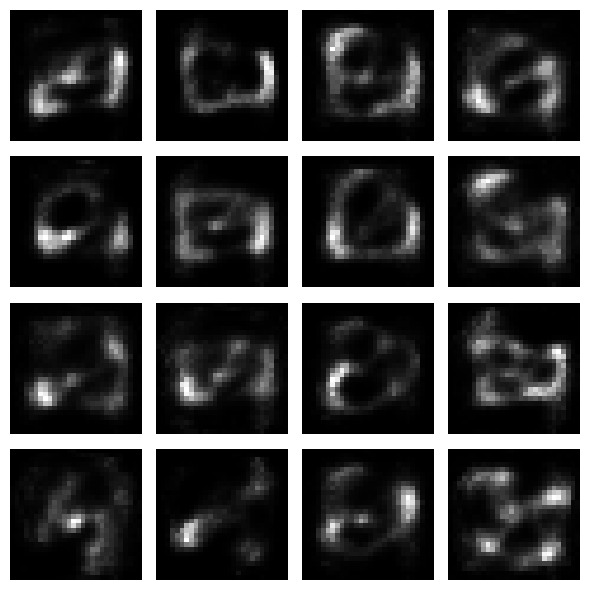

In [39]:
vae.eval()

with torch.no_grad():
    z = torch.randn(16, 16).to(device)
    generated = vae.decoder(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, 0], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

### ❓ Reflect — VAE
Answer in a markdown cell below:
1. Are the generated digits sharp or blurry? Why does this happen architecturally?
2. What does the KL divergence term in the loss do? What happens if you remove it?

In [ ]:
# The result is blurry. I tried to change the epochs = 20, nn.Linear(784,2) or nn.Linear(784,700), and setting latent_dim=8 or latent_dim=32.
# Blurriness is still the same. nn.Linear(784,2) is worse, every generated image looks the same. nn.Linear(784,700) some pictures are clearer but the loss is the same.
# Original image is converted into Latent Representation，and z is sampled from Latent Distribution. Decoder uses z for image Reconstruction. This process makes the image
# look similar to original image but blurry.


# KL divergence term is an important factor for image generation. When I return recon_loss only to run the VAE, all images lost the shape, not just blurry but I also
# cannot tell they are numbers, even the loss is very small. KL divergence encourages the latent distribution to be closer to the standard normal distribution for the
# new images generation.


## Part 2 — GAN on MNIST
**Goal:** Train a GAN. Deliberately trigger mode collapse and document it.

In [34]:
class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),   nn.ReLU(),
            nn.Linear(256, 784),   nn.Tanh(),
            nn.Unflatten(1, (1,28,28))
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),   nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

Using: cpu
Epoch 1/10, D Loss: 0.5780, G Loss: 2.9885
Epoch 2/10, D Loss: 0.3108, G Loss: 2.4260
Epoch 3/10, D Loss: 0.3171, G Loss: 3.0846
Epoch 4/10, D Loss: 0.7514, G Loss: 1.8517
Epoch 5/10, D Loss: 0.2562, G Loss: 3.6406
Epoch 6/10, D Loss: 0.1405, G Loss: 2.7634
Epoch 7/10, D Loss: 0.5032, G Loss: 2.6853
Epoch 8/10, D Loss: 0.1601, G Loss: 3.8951
Epoch 9/10, D Loss: 0.2044, G Loss: 5.5228
Epoch 10/10, D Loss: 0.2984, G Loss: 7.9010


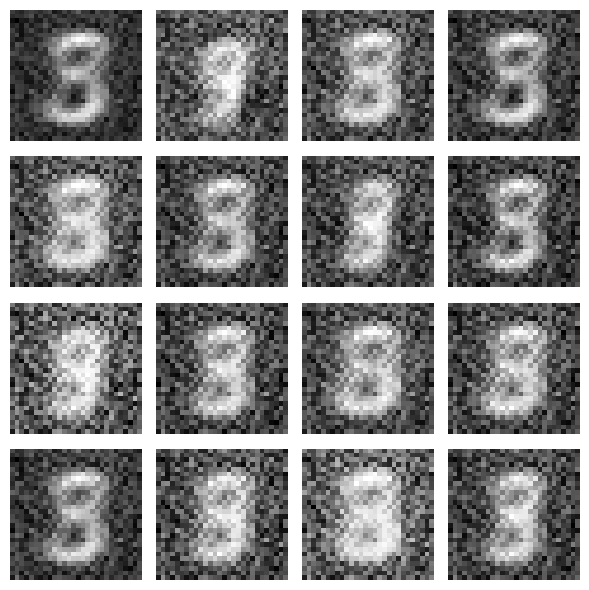

In [40]:
# TODO: Train the GAN for 10 epochs with BALANCED learning rates (lr=2e-4 for both G and D).
# Generate and display 16 images after training. These should show variety.

# Debug for GPU usage is over
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

# Binary Cross Entropy Loss Function Real = 1，Fake = 0
criterion = nn.BCELoss()

# G Learning Rate 2e-4，0.0002
optimizer_G = torch.optim.Adam(G.parameters(), lr=2e-4)

# D Learning Rate 2e-4，same speed as G
optimizer_D = torch.optim.Adam(D.parameters(), lr=2e-4)

# CPU or GPU
print("Using:", device)


# =========================
# Start Training
# =========================

# epoch 10
for epoch in range(10):

    for real, _ in loader:

        # Original images move to device
        real = real.to(device)
        batch_size = real.size(0)


        # =========================
        # Real / Fake Labels
        # =========================

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =========================
        # Generator Fake Images with z
        # =========================

        z = torch.randn(batch_size, 64).to(device)
        fake = G(z)

        # =========================
        # ① Training Discriminator
        # =========================

        # Clear D Gradient
        optimizer_D.zero_grad()

        # Handling the original images
        output_real = D(real)

        # Lost rate
        loss_real = criterion(output_real, real_labels)

        # detach() traing D only，Gradient not going back to G
        output_fake = D(fake.detach())

        # Fake Images Loss
        loss_fake = criterion(output_fake, fake_labels)

        # D total Loss
        loss_D = loss_real + loss_fake

        # Backpropagation
        loss_D.backward()

        # Optimizer D Weight or Bias
        optimizer_D.step()

        # =========================
        # ② Training Generator
        # =========================

        # clear Gradient
        optimizer_G.zero_grad()

        # G Fake Images move to D
        # not using detach()，for Gradient to G
        output_fake_for_G = D(fake)

        #G making D believes Real
        loss_G = criterion(output_fake_for_G, real_labels)

        # Backpropagation
        loss_G.backward()

        # Optimizer updated G Weight and Bias
        optimizer_G.step()


    # run and display
    print(
        f"Epoch {epoch+1}/10, "
        f"D Loss: {loss_D.item():.4f}, "
        f"G Loss: {loss_G.item():.4f}"
    )


# =========================
# Got 16 images from Training
# =========================

# Switch Generator to Evaluation Mode
G.eval()

with torch.no_grad():

    # 16 Random z with 64 Dimension
    z = torch.randn(16, 64).to(device)

    # Generate new images
    generated = G(z).cpu()


# 4x4 16 images in total
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, 0], cmap="gray")
    ax.axis("off")


plt.tight_layout()

# display
plt.show()

Epoch 1/10, D Loss: 0.0318, G Loss: 14.0328
Epoch 2/10, D Loss: 0.0001, G Loss: 88.4181
Epoch 3/10, D Loss: 0.1240, G Loss: 6.8726
Epoch 4/10, D Loss: 0.4212, G Loss: 12.2696
Epoch 5/10, D Loss: 0.0235, G Loss: 5.8617
Epoch 6/10, D Loss: 0.0616, G Loss: 6.5713
Epoch 7/10, D Loss: 0.0673, G Loss: 6.2485
Epoch 8/10, D Loss: 0.0543, G Loss: 12.6298
Epoch 9/10, D Loss: 0.1505, G Loss: 9.5119
Epoch 10/10, D Loss: 0.0022, G Loss: 10.0614


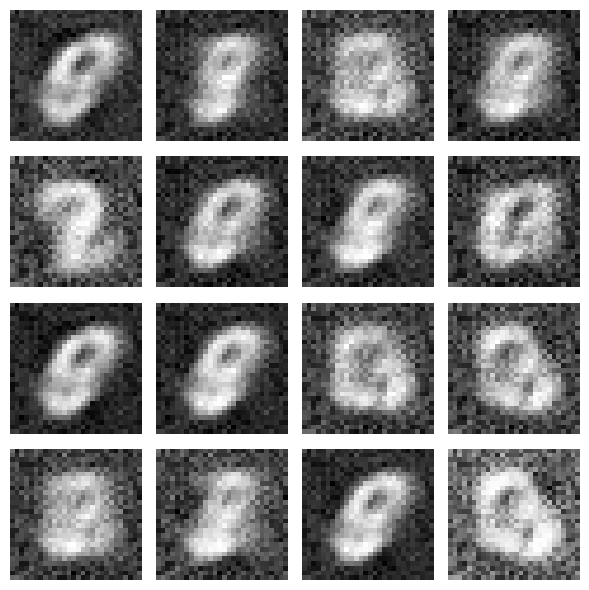

In [41]:
# TODO: Now TRIGGER MODE COLLAPSE: retrain with D learning rate 10x higher than G (e.g. D=2e-3, G=2e-4).
# Generate 16 images. Document what you see — do they all look the same?

# Renew Generator
G_collapse = Generator().to(device)

# Renew Discriminator
D_collapse = Discriminator().to(device)

# Generator Learning Rate 2e-4 0.0002
optimizer_G_collapse = torch.optim.Adam(
    G_collapse.parameters(), lr=2e-4
)

# Discriminator Learning Rate rase to 2e-3 0.002 (10 times)
optimizer_D_collapse = torch.optim.Adam(
    D_collapse.parameters(), lr=2e-3
)

# ============================================================
# start Training (10 Epochs)
# ============================================================

for epoch in range(10):

    for real, _ in loader:

        real = real.to(device)
        batch_size = real.size(0)

        # 1 = Real
        real_labels = torch.ones(batch_size, 1).to(device)

        # 0 = Fake
        fake_labels = torch.zeros(batch_size, 1).to(device)


        # ----------------------------------------------------
        # Generate Fake Images
        # ----------------------------------------------------

        # Random z with 64 Dimension
        z = torch.randn(batch_size, 64).to(device)

        # Fake Images from z
        fake = G_collapse(z)


        # ====================================================
        # Training Discriminator
        # ====================================================

        # clear Gradient
        optimizer_D_collapse.zero_grad()

        # getting D Real
        output_real = D_collapse(real)

        loss_real = criterion(output_real, real_labels)


        # Generator Fake Images
        # detach() training D only，not updating G
        output_fake = D_collapse(fake.detach())

        loss_fake = criterion(output_fake, fake_labels)


        # D Total loss
        loss_D = loss_real + loss_fake

        # Backpropagation
        loss_D.backward()

        # D Weight and Bias (Learning Rate = 0.002)
        optimizer_D_collapse.step()


        # ====================================================
        # Training Generator
        # ====================================================

        # clear G Gradient
        optimizer_G_collapse.zero_grad()

        # Fake Images for D
        # Not using detach()，for Gradient sending back to G
        output_fake_for_G = D_collapse(fake)

        # G try to make D real_labels = 1
        loss_G = criterion(output_fake_for_G, real_labels)

        # Backpropagation（反向傳播）
        loss_G.backward()

        # update G Weight and Bias Learning Rate (0.0002)
        optimizer_G_collapse.step()


    # display
    print(
        f"Epoch {epoch+1}/10, "
        f"D Loss: {loss_D.item():.4f}, "
        f"G Loss: {loss_G.item():.4f}"
    )


# ============================================================
#  Generate 16 images
# ============================================================

# swich Generator to Evaluation Mode
G_collapse.eval()

with torch.no_grad():

    # 16 x Random z with 64 Dimension
    z = torch.randn(16, 64).to(device)

    # G_collapse generate 16 images
    generated_collapse = G_collapse(z).cpu()


# ============================================================
# Display
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(generated_collapse[i, 0], cmap="gray")

    ax.axis("off")

plt.tight_layout()

plt.show()


### ❓ Reflect — GAN
1. Describe the mode collapse you triggered. What exactly happened visually?
2. Why does discriminator learning rate imbalance cause mode collapse? Explain the gradient flow.

In [4]:
# 1. Describe the mode collapse you triggered. What exactly happened visually?
# Balanced GAN: 16 images have different shape. Not just blurry but Mode Collaps.

# D Learning Rate × 10
# Many generated images look similar
# Variety is lower

# 2. Why does discriminator learning rate imbalance cause mode collapse? Explain the gradient flow.

# G figured out some modes can make D believe the generated images were real，then it keeps using it causes Variety lost。
# During the Gradient Flow, backwrd flow is Loss->Discriminator->Fake Image->Generator (Discriminator learning rate x10). Learning rate times 10 making the Generator
# keep using short cut to get a real result and causes many generated image looks similar.

## Part 3 — FID Score Comparison
**Goal:** Compute FID for VAE and GAN outputs and interpret the result.

In [6]:
!pip install pytorch-fid --quiet

In [43]:
# TODO: Generate 1000 images from your VAE and 1000 from your GAN (post-collapse and pre-collapse versions).
# Rebuild MNIST DataLoader
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

print("MNIST loader ready:", len(train_data))

import os
from torchvision.utils import save_image

count = 0

# MNIST DataLoader
for real, _ in loader:

    for image in real:

        save_image(image, f"./real_images/{count}.png")
        count += 1

        if count >= 1000:
            break

    if count >= 1000:
        break

print("Real images saved:", count)


# ============================================================
#  VAE Generated Images
# ============================================================

vae.eval()
vae_z_dim = vae.decoder[0].in_features

print("VAE latent dimension:", vae_z_dim)

with torch.no_grad():

    z = torch.randn(1000, vae_z_dim).to(device)
    vae_generated = vae.decoder(z).cpu()

for i in range(1000):
    save_image(vae_generated[i], f"./vae_images/{i}.png")

print("VAE images saved:", len(vae_generated))


# ============================================================
# 1000 Balanced GAN Images
# ============================================================

G.eval()

with torch.no_grad():

    z = torch.randn(1000, 64).to(device)
    gan_generated = G(z).cpu()
    gan_generated = (gan_generated + 1) / 2

for i in range(1000):
    save_image(gan_generated[i], f"./gan_good/{i}.png")

print("Balanced GAN images saved:", len(gan_generated))


# ============================================================
# 1000 Collapsed GAN Images
# ============================================================

G_collapse.eval()

with torch.no_grad():

    z = torch.randn(1000, 64).to(device)
    collapsed_generated = G_collapse(z).cpu()
    collapsed_generated = (collapsed_generated + 1) / 2

for i in range(1000):
    save_image(
        collapsed_generated[i],
        f"./gan_collapsed/{i}.png"
    )

print("Collapsed GAN images saved:", len(collapsed_generated))


# ============================================================
# print
# ============================================================

print("\n----- Finished -----")
print("real_images:", len(os.listdir("./real_images")))
print("vae_images:", len(os.listdir("./vae_images")))
print("gan_good:", len(os.listdir("./gan_good")))
print("gan_collapsed:", len(os.listdir("./gan_collapsed")))

MNIST loader ready: 60000
Real images saved: 1000
VAE latent dimension: 16
VAE images saved: 1000
Balanced GAN images saved: 1000
Collapsed GAN images saved: 1000

----- Finished -----
real_images: 1000
vae_images: 1000
gan_good: 1000
gan_collapsed: 1000


In [44]:
!python -m pytorch_fid ./real_images/ ./vae_images/

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 202MB/s]
100% 20/20 [06:38<00:00, 19.93s/it]
100% 20/20 [06:35<00:00, 19.78s/it]
FID:  258.902375172506


In [45]:
!python -m pytorch_fid ./real_images/ ./gan_good/

100% 20/20 [06:25<00:00, 19.25s/it]
100% 20/20 [06:25<00:00, 19.27s/it]
FID:  399.2223083460267


In [46]:
!python -m pytorch_fid ./real_images/ ./gan_collapsed/

100% 20/20 [06:19<00:00, 19.00s/it]
100% 20/20 [06:28<00:00, 19.41s/it]
FID:  359.09213670456637


### ❓ Final Reflection — Production Decision
Your client needs **synthetic medical imaging data**. They have 300 labelled scans.

1. Which model (VAE or GAN) do you recommend and why?
2. What breaks first at 300 training examples?
3. What metric would you use to validate the synthetic data before using it for classifier training?

In [ ]:
#1 I will recommend VAE for better Diversity and avoiding Mode Collapse.
#2 The breaks risks will be Overfitting and Dataset Bias, 300 taining sample is too low.
#3 FID is the one I would use to validate the synthetic data before using it for calssifier training. Comparing the FID of synthetic images and fake images, the lower
#  the more reliable.


---
## Submission
- [ ] Push to `genai-course/week1/lab1.ipynb`
- [ ] All TODO cells completed and run
- [ ] Reflection questions answered
- [ ] Best generated image grid in README